# 03 — Time Series Forecasting

**Hour 2, 90–115 min: Train/test split, baseline, model, and evaluation**

This is where everything comes together. We'll:
1. Build the same lag and calendar features as Notebook 02
2. Split the data chronologically (never randomly!)
3. Build a naive baseline
4. Train a simple regression-based forecasting model
5. Evaluate both with MAE, RMSE, and MAPE
6. Visualize actual vs. forecast

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (11, 5)

df = pd.read_csv("../data/bank_cash_withdrawal_timeseries.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.shape

(730, 6)

## Build Features

Same lag and calendar features from Notebook 02, built again here so this notebook can run on its own.

In [2]:
df["Lag_1"] = df["WithdrawalAmount"].shift(1)
df["Lag_7"] = df["WithdrawalAmount"].shift(7)
df["DayOfWeekNum"] = df["Date"].dt.dayofweek
df["MonthNum"] = df["Date"].dt.month

# Drop the rows with missing lag values (the first 7 days) — a model can't use a NaN feature
df = df.dropna().reset_index(drop=True)
df.shape

(723, 10)

## Time-Based Train/Test Split

> Do NOT randomly shuffle Time Series data.

We use the last 60 days as our TEST set (the "future" we pretend not to know yet), and
everything before that as TRAINING data (the "past").

In [3]:
TEST_DAYS = 60
split_index = len(df) - TEST_DAYS

train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

print(f"Training period: {train['Date'].min().date()} to {train['Date'].max().date()} ({len(train)} days)")
print(f"Test period:     {test['Date'].min().date()} to {test['Date'].max().date()} ({len(test)} days)")

Training period: 2023-01-08 to 2024-10-31 (663 days)
Test period:     2024-11-01 to 2024-12-30 (60 days)


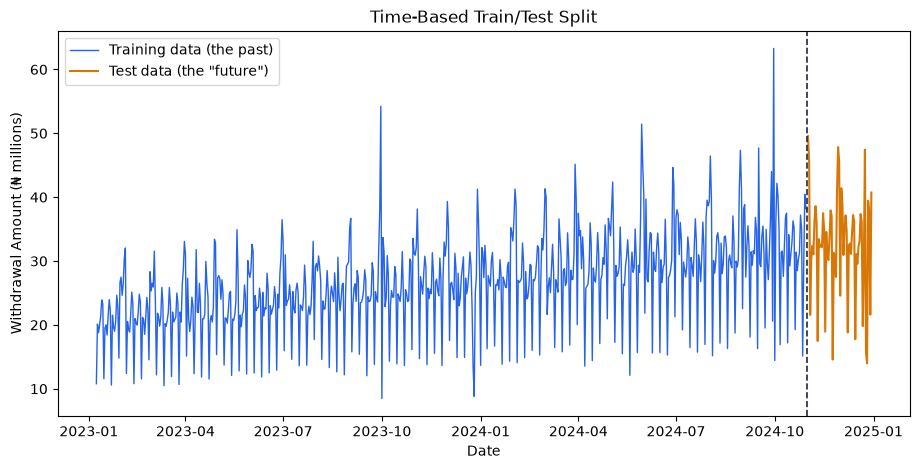

In [4]:
fig, ax = plt.subplots()
ax.plot(train["Date"], train["WithdrawalAmount"] / 1e6, color="#2563EB", linewidth=1, label="Training data (the past)")
ax.plot(test["Date"], test["WithdrawalAmount"] / 1e6, color="#D97706", linewidth=1.5, label="Test data (the \"future\")")
ax.axvline(train["Date"].iloc[-1], color="#1F2937", linestyle="--", linewidth=1.2)
ax.set_xlabel("Date")
ax.set_ylabel("Withdrawal Amount (₦ millions)")
ax.set_title("Time-Based Train/Test Split")
ax.legend()
plt.show()

## Build a Baseline: the Naive Forecast

**What are we doing?** The simplest possible forecast: "tomorrow's withdrawal = today's
withdrawal" — in other words, our forecast for each day in the test set is just `Lag_1`
(yesterday's actual value), which we already have as a column.

**Why bother?** If a more advanced model can't beat this, the added complexity isn't earning
its keep.

In [5]:
naive_forecast = test["Lag_1"]

naive_mae = mean_absolute_error(test["WithdrawalAmount"], naive_forecast)
naive_rmse = root_mean_squared_error(test["WithdrawalAmount"], naive_forecast)
naive_mape = mean_absolute_percentage_error(test["WithdrawalAmount"], naive_forecast) * 100

print(f"Naive baseline -> MAE: ₦{naive_mae:,.0f}   RMSE: ₦{naive_rmse:,.0f}   MAPE: {naive_mape:.1f}%")

Naive baseline -> MAE: ₦8,223,256   RMSE: ₦11,427,009   MAPE: 31.7%


## Train a Simple Forecasting Model

We use ordinary linear regression, fed with the lag and calendar features we built earlier.
This is the "Simple Model Approach" from the slides — forecasting reframed as regular
regression once time-aware features exist.

In [6]:
feature_cols = ["Lag_1", "Lag_7", "DayOfWeekNum", "MonthNum", "IsWeekend"]

model = LinearRegression()
model.fit(train[feature_cols], train["WithdrawalAmount"])

forecast = model.predict(test[feature_cols])
forecast[:5]

array([35807703.97973891, 36403642.89448212, 22444716.50717096,
       27845067.88418077, 36554829.77110348])

## Evaluate the Forecast

In [7]:
model_mae = mean_absolute_error(test["WithdrawalAmount"], forecast)
model_rmse = root_mean_squared_error(test["WithdrawalAmount"], forecast)
model_mape = mean_absolute_percentage_error(test["WithdrawalAmount"], forecast) * 100

print(f"Model          -> MAE: ₦{model_mae:,.0f}   RMSE: ₦{model_rmse:,.0f}   MAPE: {model_mape:.1f}%")
print(f"Naive baseline -> MAE: ₦{naive_mae:,.0f}   RMSE: ₦{naive_rmse:,.0f}   MAPE: {naive_mape:.1f}%")
print()
improvement = (naive_mae - model_mae) / naive_mae * 100
print(f"The model reduces MAE by {improvement:.0f}% compared to the naive baseline.")

Model          -> MAE: ₦4,651,968   RMSE: ₦6,412,993   MAPE: 16.4%
Naive baseline -> MAE: ₦8,223,256   RMSE: ₦11,427,009   MAPE: 31.7%

The model reduces MAE by 43% compared to the naive baseline.


**Business language:**
- **MAE** — on average, how far off (in naira) our forecast typically is from the actual value —
  print the cell above to see today's exact number, and compare it against the naive baseline's MAE.
- **RMSE** — usually a bit higher than MAE, meaning a few days have noticeably larger errors
  (likely the holiday and unexplained-spike days we saw in Hour 1).
- **MAPE** — our typical error expressed as a percentage of the actual daily withdrawal amount.

**Did the model beat the baseline?** Check the "reduces MAE by ...%" line printed above — on
this dataset the model clearly beats the naive baseline on every metric. That's a good sign the
lag and calendar features are adding real value, not just complexity.

## Visualize: Actual vs. Forecast

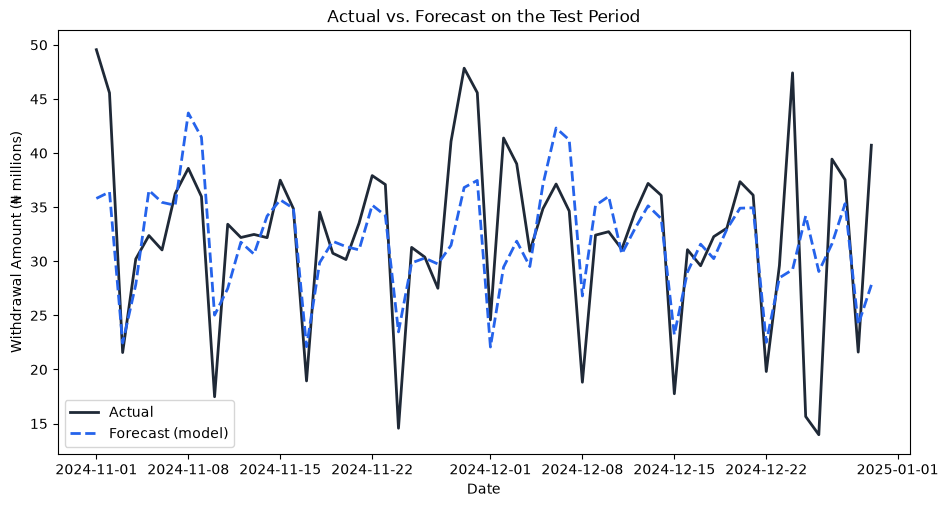

In [8]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(test["Date"], test["WithdrawalAmount"] / 1e6, color="#1F2937", linewidth=2, label="Actual")
ax.plot(test["Date"], forecast / 1e6, color="#2563EB", linewidth=2, linestyle="--", label="Forecast (model)")
ax.set_xlabel("Date")
ax.set_ylabel("Withdrawal Amount (₦ millions)")
ax.set_title("Actual vs. Forecast on the Test Period")
ax.legend()
plt.show()

**Where did the model do well?** It tracks the weekly rhythm (the up-and-down pattern) quite
closely — that's the lag and day-of-week features doing their job.

**Where did it do poorly?** Look for days where the actual (solid) line spikes or drops far
below the forecast (dashed) line — those are usually holidays or the unexplained "noise" spikes
from Hour 1. No feature in our dataset explicitly flags those unexplained spikes, so the model
has no way to anticipate them. This is a completely normal and expected limitation, not a bug —
remember: **the goal is a USEFUL forecast, not a perfect one.**

### Recap
- We built lag and calendar features, then split chronologically — training only on the past.
- We compared a naive baseline against a simple regression model using MAE, RMSE, and MAPE.
- We visualized actual vs. forecast and interpreted where the model succeeds and where it
  struggles.

**Next: `04_Cash_Demand_Forecasting_Project.ipynb`** — the mini challenge and the full
end-to-end capstone pipeline.